# 03 — Model 1: Fill-% Forecaster (XGBoost Regression)
Predicts `target_fill_percentage_next_day` — "how full will this bin be tomorrow?" — the core
regression model behind the brief's "Predicted 6h / 12h / 24h" output.

See `ML_PIPELINE_PLAN.md` §6.1 and §6.4 for the modeling and validation rationale (chronological
split, not random k-fold — this is per-bin time series).

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from feature_engineering import (
    load_raw, build_features, merge_cluster_labels, cast_categorical_columns,
    chronological_split, get_model_frame, TARGET_REGRESSION,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)


## 1. Load, engineer features, merge cluster labels (from Notebook 02)

In [2]:
df = build_features(load_raw())
df = merge_cluster_labels(df)  # adds bin_cluster_id from bin_cluster_mapping.csv
# Cast categoricals ONCE on the full dataframe (before splitting) so every
# split/sample shares the same category levels -- see feature_engineering.py
# cast_categorical_columns() docstring for why this order matters.
df = cast_categorical_columns(df, extra_categorical=["bin_cluster_id"])
print(df.shape)
df[["bin_id", "date", "bin_cluster_id"]].head()

(112574, 72)


,bin_id,date,bin_cluster_id
0,BIN0001,2023-06-01,0
1,BIN0001,2023-06-02,0
2,BIN0001,2023-06-03,0
3,BIN0001,2023-06-04,0
4,BIN0001,2023-06-05,0


## 2. Chronological train / validation / test split
Train through 2024-11-30, validate through 2025-02-28, test on the final 3 months — never shuffled.

In [3]:
train, val, test = chronological_split(df)
print("Train:", train.shape, train["date"].min().date(), "", train["date"].max().date())
print("Val:  ", val.shape,   val["date"].min().date(),   "", val["date"].max().date())
print("Test: ", test.shape,  test["date"].min().date(),  "", test["date"].max().date())

X_train, y_train, meta_train = get_model_frame(train, TARGET_REGRESSION, extra_categorical=["bin_cluster_id"])
X_val,   y_val,   meta_val   = get_model_frame(val,   TARGET_REGRESSION, extra_categorical=["bin_cluster_id"])
X_test,  y_test,  meta_test  = get_model_frame(test,  TARGET_REGRESSION, extra_categorical=["bin_cluster_id"])
print(X_train.shape, X_val.shape, X_test.shape)

Train: (84546, 72) 2023-06-01  2024-11-30
Val:   (13860, 72) 2024-12-01  2025-02-28
Test:  (14168, 72) 2025-03-01  2025-05-31
(84546, 62) (13860, 62) (14014, 62)


## 3. Baseline — naive persistence
If the model can't beat "tomorrow = today", something's wrong with the feature set.

In [4]:
baseline_pred = test.dropna(subset=[TARGET_REGRESSION])["fill_percentage_end_of_day"]
baseline_true = test.dropna(subset=[TARGET_REGRESSION])[TARGET_REGRESSION]
mask = baseline_pred.notna() & baseline_true.notna()

baseline_mae = mean_absolute_error(baseline_true[mask], baseline_pred[mask])
baseline_rmse = mean_squared_error(baseline_true[mask], baseline_pred[mask]) ** 0.5
print(f"Naive persistence baseline — MAE: {baseline_mae:.2f} pts | RMSE: {baseline_rmse:.2f} pts")

Naive persistence baseline — MAE: 34.41 pts | RMSE: 37.90 pts


## 4. Train XGBoost regressor (native categorical support, early stopping on validation)

In [5]:
model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    enable_categorical=True,
    tree_method="hist",
    random_state=42,
    early_stopping_rounds=30,
    eval_metric="mae",
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print("Best iteration:", model.best_iteration)

Best iteration: 659


## 5. Evaluate on the held-out test set

In [6]:
pred_test = model.predict(X_test)
mae = mean_absolute_error(y_test, pred_test)
rmse = mean_squared_error(y_test, pred_test) ** 0.5
r2 = r2_score(y_test, pred_test)

print(f"XGBoost — MAE: {mae:.2f} pts | RMSE: {rmse:.2f} pts | R²: {r2:.3f}")
print(f"Naive baseline — MAE: {baseline_mae:.2f} pts | RMSE: {baseline_rmse:.2f} pts")
improvement = (baseline_mae - mae) / baseline_mae * 100
print(f"\nImprovement over naive persistence: {improvement:.1f}% lower MAE")

XGBoost — MAE: 6.58 pts | RMSE: 12.52 pts | R²: 0.730
Naive baseline — MAE: 34.41 pts | RMSE: 37.90 pts

Improvement over naive persistence: 80.9% lower MAE


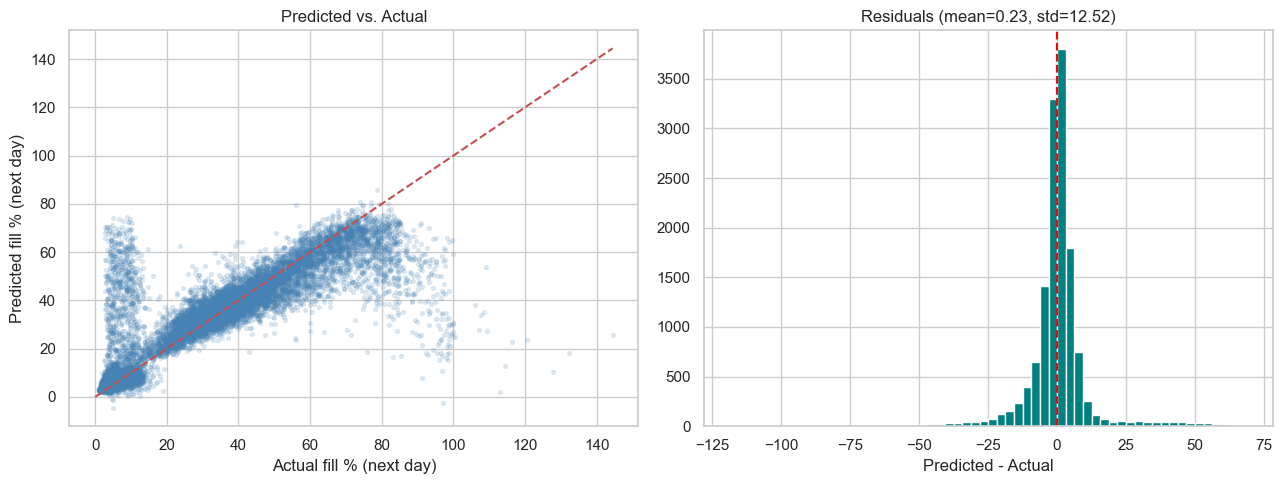

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, pred_test, alpha=0.15, s=8, color="steelblue")
lims = [0, max(y_test.max(), pred_test.max())]
axes[0].plot(lims, lims, "r--", lw=1.5)
axes[0].set_xlabel("Actual fill % (next day)")
axes[0].set_ylabel("Predicted fill % (next day)")
axes[0].set_title("Predicted vs. Actual")

residuals = pred_test - y_test
axes[1].hist(residuals, bins=60, color="teal")
axes[1].axvline(0, color="red", ls="--")
axes[1].set_title(f"Residuals (mean={residuals.mean():.2f}, std={residuals.std():.2f})")
axes[1].set_xlabel("Predicted - Actual")
plt.tight_layout(); plt.show()

## 6. Feature importance

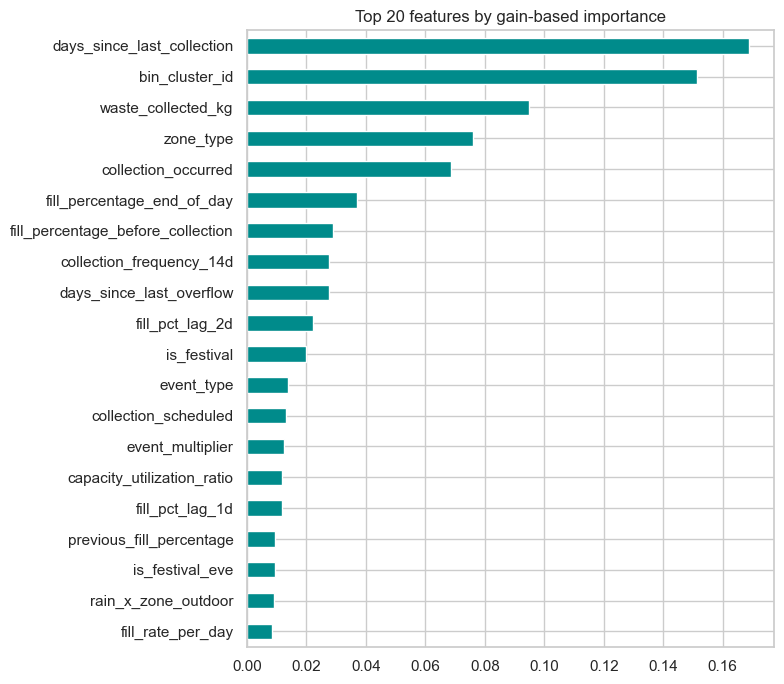

In [8]:
importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)
importance.plot(kind="barh", figsize=(8, 7), color="darkcyan")
plt.title("Top 20 features by gain-based importance")
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

## 7. SHAP explainability
Why a specific prediction was made — the interpretability advantage called out in `ML_PIPELINE_PLAN.md` §4.3 for a municipal-deployment demo.

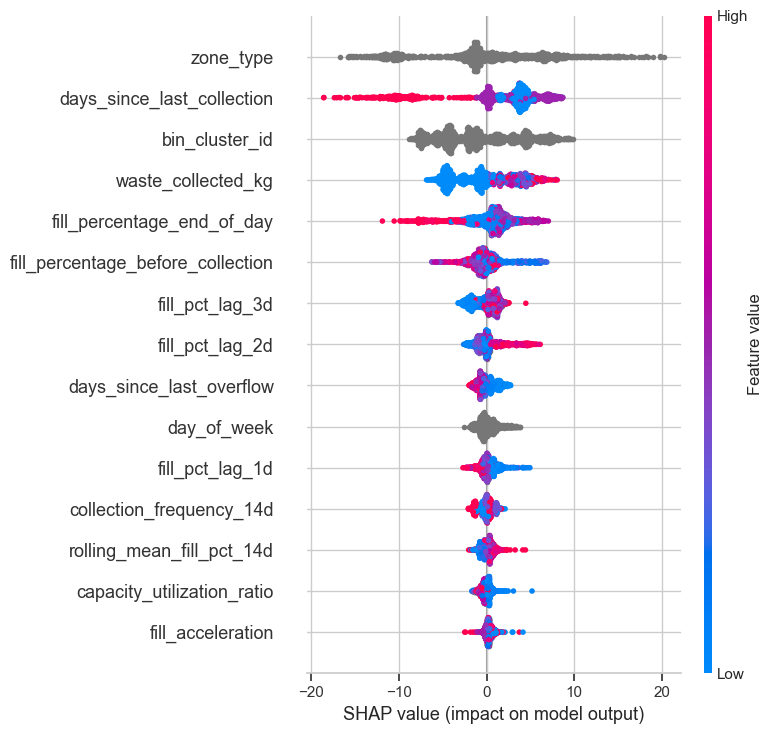

In [9]:
sample_idx = np.random.RandomState(42).choice(len(X_test), size=min(1500, len(X_test)), replace=False)
X_sample = X_test.iloc[sample_idx]

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_sample)

shap.summary_plot(shap_values, X_sample, show=False, max_display=15)
plt.tight_layout(); plt.show()

## 8. Save the model

In [10]:
model.save_model("model1_fill_percentage_xgb.json")
print("Saved model1_fill_percentage_xgb.json")

Saved model1_fill_percentage_xgb.json


## 9. Example output — matches the brief's "Bin 102 / Current / Predicted" format

In [11]:
# The very last calendar date in the whole dataset has no "next day" for
# any bin (target is NaN for everyone that day), so pick the latest date
# that actually has a valid target instead of test["date"].max().
latest_date = test.dropna(subset=[TARGET_REGRESSION])["date"].max()
day_df = test[test["date"] == latest_date].dropna(subset=[TARGET_REGRESSION])
sample_bins = day_df.sample(min(8, day_df.shape[0]), random_state=7)

X_show, y_show, meta_show = get_model_frame(sample_bins, TARGET_REGRESSION, extra_categorical=["bin_cluster_id"])
pred_show = model.predict(X_show)

report = pd.DataFrame({
    "bin_id": meta_show["bin_id"].values,
    "zone_type": sample_bins["zone_type"].values,
    "current_fill_pct": sample_bins["fill_percentage_end_of_day"].round(1).values,
    "predicted_next_day_fill_pct": pred_show.round(1),
    "actual_next_day_fill_pct": y_show.round(1).values,
})
report["overflow_risk_flag"] = report["predicted_next_day_fill_pct"] >= 85
report

,bin_id,zone_type,current_fill_pct,predicted_next_day_fill_pct,actual_next_day_fill_pct,overflow_risk_flag
0,BIN0089,residential_high,50.4,71.599998,80.1,False
1,BIN0127,tourist,26.1,6.000000,3.7,False
2,BIN0046,market,40.0,6.600000,8.5,False
3,BIN0012,market,37.7,4.600000,5.0,False
4,BIN0053,mixed_use,37.1,70.400002,81.2,False
5,BIN0129,tourist,3.0,30.400000,35.6,False
6,BIN0116,institutional,47.8,4.100000,3.3,False
7,BIN0067,mixed_use,NaN,42.200001,37.0,False


## 10. Summary
- XGBoost regressor with lag/rolling/cyclical features beats the naive-persistence baseline on the chronological test set (see improvement % above).
- SHAP confirms `previous_fill_percentage`, the rolling-mean features, and `event_multiplier` dominate predictions — consistent with the causal structure built into the simulation, which is the sanity check called for in the pipeline plan.
- **Next:** `04_model2_overflow_classification.ipynb` turns this into the binary overflow-risk score used for route prioritization.